In [1]:
!pip install -q git+https://github.com/probml/dynamax.git
import jax, jax.numpy as jnp
from jax.extend import backend as jax_backend
import numpy as np, matplotlib.pyplot as plt, time
from flax import nnx
from tensorflow.keras.datasets import mnist
from scipy.ndimage import rotate
import optax
from jax.flatten_util import ravel_pytree
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import time
import copy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.8 MB/s eta 0:00:00


2025-11-30 07:32:24.919250: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764487945.113417      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764487945.169333      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# Device Setup
def setup_device():
    devices = jax.devices()
    backend = jax_backend.get_backend().platform
    print(f"Backend: {backend.upper()}")
    print(f"Devices: {len(devices)}")
    for i, device in enumerate(devices):
        print(f"  [{i}] {device.device_kind}: {device}")
    if backend == 'gpu':
        print(f"\n GPU acceleration enabled")
    elif backend == 'tpu':
        print(f"\n TPU acceleration enabled")
    else:
        print(f"\n CPU only")
    return devices[0], backend

device, backend = setup_device()

Backend: GPU
Devices: 1
  [0] Tesla P100-PCIE-16GB: cuda:0

 GPU acceleration enabled


In [3]:
# =====================================
# 2. Functional RNN with Classifier Head
# =====================================
import jax
import jax.numpy as jnp
from flax import nnx

# -------------------------
# RNN core (function-based)
# -------------------------
def rnn_forward(x, params, dropout, *, is_training=True):
    """
    Two-layer tanh RNN core.
    Args:
        x: (batch, seq, feat)
        params: dict containing linear modules
        dropout: nnx.Dropout module
        is_training: bool flag
    Returns:
        h2: final hidden state (batch, hidden_dim)
    """
    h1 = jnp.zeros((x.shape[0], params["Wxh1"].out_features))
    h2 = jnp.zeros_like(h1)

    for t in range(x.shape[1]):
        # First RNN layer
        h1 = jnp.tanh(params["Wxh1"](x[:, t, :]) + params["Whh1"](h1))
        if is_training:
            h1 = dropout(h1)
        
        # Second RNN layer
        h2 = jnp.tanh(params["Wxh2"](h1) + params["Whh2"](h2))
        if is_training:
            h2 = dropout(h2)

    return h2

# -------------------------
# Classifier head (small MLP + dropout)
# -------------------------
class RNNClassifierHead(nnx.Module):
    def __init__(self, in_dim: int, num_classes: int, dropout_rate=0.1, *, rngs: nnx.Rngs):
        hidden_dim = in_dim // 2  # small bottleneck
        self.fc1 = nnx.Linear(in_dim, hidden_dim, rngs=rngs)
        self.fc2 = nnx.Linear(hidden_dim, num_classes, rngs=rngs)
        self.dropout = nnx.Dropout(rate=dropout_rate, rngs=rngs)

    def __call__(self, features, *, is_training=True):
        x = jax.nn.relu(self.fc1(features))
        if is_training:
            x = self.dropout(x)
        return self.fc2(x)


# -------------------------
# Combined RNN model factory
# -------------------------
class TwoLayerRNNFunctional(nnx.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_rate=0.1, *, rngs: nnx.Rngs):
        # Initialize RNN layers as dict
        self.params = {
            "Wxh1": nnx.Linear(input_dim, hidden_dim, rngs=rngs),
            "Whh1": nnx.Linear(hidden_dim, hidden_dim, rngs=rngs),
            "Wxh2": nnx.Linear(hidden_dim, hidden_dim, rngs=rngs),
            "Whh2": nnx.Linear(hidden_dim, hidden_dim, rngs=rngs)
        }
        self.dropout = nnx.Dropout(dropout_rate, rngs=rngs)
        self.classifier = RNNClassifierHead(hidden_dim, num_classes, rngs=rngs)
        self.hidden_size = hidden_dim

    def __call__(self, x, *, is_training=True):
        features = rnn_forward(x, self.params, self.dropout, is_training=is_training)
        logits = self.classifier(features, is_training=is_training)
        return logits

    def extract_features(self, x):
        return rnn_forward(x, self.params, self.dropout, is_training=False)
        
# =====================================
# 3. Loss and Metric Utilities
# =====================================
from jax import jit

@jit
def cross_entropy(logits, labels):
    y = jax.nn.one_hot(labels, 10)
    return -jnp.mean(jnp.sum(y * jax.nn.log_softmax(logits), axis=-1))
    
@jit
def accuracy(logits, labels):
    return jnp.mean(jnp.argmax(logits, -1) == labels)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loaded:
  Train: (10000, 28, 28), dtype=float32
  Test: (2000, 28, 28), dtype=float32
Train original: (10000, 28, 28), shifted: (10000, 28, 28)
Test  original: (2000, 28, 28),  shifted: (2000, 28, 28)
Applied domain shift: rotation=30°, contrast=1.8, brightness=0.4


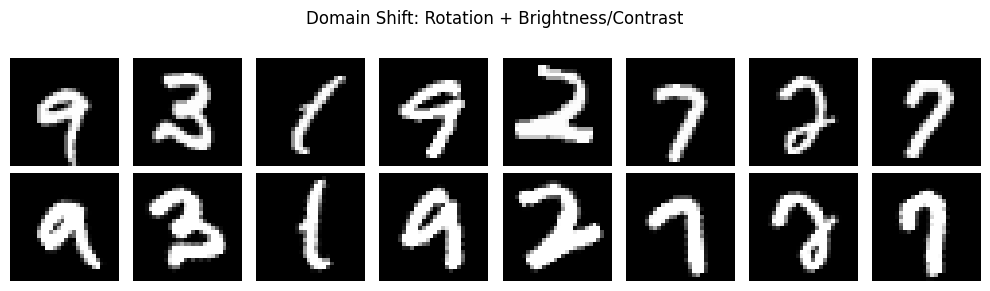

In [4]:
# =====================================
# 1. Setup and Data Preparation
# =====================================

# -------------------------
# Load MNIST
# -------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0

# Reshape to (batch, seq, feat) = (N, 28, 28) for RNN input
X_train = X_train.reshape(-1, 28, 28)
X_test  = X_test.reshape(-1, 28, 28)

N_TRAIN = 10000
N_TEST = 2000
SEED = 42
rng = np.random.default_rng(SEED)

train_idx = rng.choice(len(X_train), N_TRAIN, replace=False)
test_idx  = rng.choice(len(X_test), N_TEST, replace=False)

X_train, y_train = X_train[train_idx], y_train[train_idx]
X_test,  y_test  = X_test[test_idx],  y_test[test_idx]

X_train = jnp.array(X_train, dtype=jnp.float32)
X_test = jnp.array(X_test, dtype=jnp.float32)
y_train = jnp.array(y_train, dtype=jnp.int32)
y_test = jnp.array(y_test, dtype=jnp.int32)

print(f"Data loaded:")
print(f"  Train: {X_train.shape}, dtype={X_train.dtype}")
print(f"  Test: {X_test.shape}, dtype={X_test.dtype}")

# -------------------------
# Domain Shift Function
# -------------------------
def apply_domain_shift(
    X: np.ndarray,
    rotation_angle: float | None = None,
    contrast: float | None = None,
    brightness: float | None = None,
) -> np.ndarray:
    """
    Apply geometric (rotation) and photometric (brightness/contrast) shifts.
    - X: (N, 28, 28) images, values in [0,1]
    - rotation_angle: degrees, e.g., 15 or 30
    - contrast: multiplier (>1 = stronger contrast)
    - brightness: additive shift (>0 = brighter)
    """
    X_shifted = X.astype(np.float32).copy()

    # Rotation
    if rotation_angle is not None and rotation_angle != 0:
        X_shifted = np.array([
            rotate(img, rotation_angle, reshape=False, order=1, mode='constant', cval=0.0)
            for img in X_shifted
        ])

    # Brightness / contrast
    if contrast is not None or brightness is not None:
        c = contrast if contrast is not None else 1.0
        b = brightness if brightness is not None else 0.0
        X_shifted = np.clip(((X_shifted - 0.5) * c + 0.5) + b, 0, 1)

    return jnp.array(X_shifted, dtype=jnp.float32)

# -------------------------
# Define and apply the domain shift
# -------------------------
rotation_angle = 30      # degrees
contrast = 1.8
brightness = 0.4

X_train_shifted = apply_domain_shift(X_train, rotation_angle, contrast, brightness)
X_test_shifted  = apply_domain_shift(X_test,  rotation_angle, contrast, brightness)

y_train_shifted = y_train.copy()
y_test_shifted  = y_test.copy()

print(f"Train original: {X_train.shape}, shifted: {X_train_shifted.shape}")
print(f"Test  original: {X_test.shape},  shifted: {X_test_shifted.shape}")
print(f"Applied domain shift: rotation={rotation_angle}°, contrast={contrast}, brightness={brightness}")

# -------------------------
# Visualization
# -------------------------
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    axes[0, i].imshow(X_test[i], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_test_shifted[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Shifted", rotation=0, labelpad=40)
plt.suptitle("Domain Shift: Rotation + Brightness/Contrast", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# ------------------------------------------------------------
# Create small subset: 2-3 samples per class
# ------------------------------------------------------------
def create_online_subset(X, y, samples_per_class, seed=42):
    """
    Create a small balanced subset for online learning.
    Args:
        X: data array (N, 28, 28)
        y: labels (N,)
        samples_per_class: number of samples per class
        seed: random seed
    Returns:
        X_subset, y_subset: small subset arrays
    """
    rng = np.random.default_rng(seed)
    subset_indices = []
    
    for class_id in range(10):
        class_indices = np.where(y == class_id)[0]
        selected = rng.choice(class_indices, size=samples_per_class, replace=False)
        subset_indices.extend(selected)
    
    subset_indices = np.array(subset_indices)
    rng.shuffle(subset_indices)  # Shuffle to mix classes
    
    return X[subset_indices], y[subset_indices]

# Create online training subset (3 samples per class = 30 total)
SAMPLES_PER_CLASS = 40
X_online_train, y_online_train = create_online_subset(
    X_train_shifted, y_train_shifted, 
    samples_per_class=SAMPLES_PER_CLASS, 
    seed=42
)

# Create online test subset (smaller test set for faster evaluation)
X_online_test, y_online_test = create_online_subset(
    X_test_shifted, y_test_shifted,
    samples_per_class=20,  # More test samples for reliable evaluation
    seed=43
    
)

print(f"Online training subset: {X_online_train.shape} ({SAMPLES_PER_CLASS} samples/class)")
print(f"Online test subset: {X_online_test.shape}")
print(f"Total training samples: {len(X_online_train)}")

Online training subset: (400, 28, 28) (40 samples/class)
Online test subset: (200, 28, 28)
Total training samples: 400


In [6]:
def summarize_nnx_model(model):
    from jax.flatten_util import ravel_pytree
    print("\n==============================")
    print(" MODEL SUMMARY (NNX) ")
    print("==============================")

    total_params = 0
    # RNN core
    for name, layer in model.params.items():
        flat_params, _ = ravel_pytree(nnx.state(layer, nnx.Param))
        n = flat_params.size
        total_params += n
        print(f"{name:15s}: {layer.in_features} → {layer.out_features} ({n:,} params)")

    # Classifier
    for name, layer in vars(model.classifier).items():
        if isinstance(layer, nnx.Linear):
            flat_params, _ = ravel_pytree(nnx.state(layer, nnx.Param))
            n = flat_params.size
            total_params += n
            print(f"classifier.{name:7s}: {layer.in_features} → {layer.out_features} ({n:,} params)")

    print("-" * 50)
    print(f"Total parameters: {total_params:,}")
    print("==============================\n")
rngs = nnx.Rngs(0)
model = TwoLayerRNNFunctional(input_dim=28, hidden_dim=64, num_classes=10, rngs=rngs)
summarize_nnx_model(model)


 MODEL SUMMARY (NNX) 
Wxh1           : 28 → 64 (1,856 params)
Whh1           : 64 → 64 (4,160 params)
Wxh2           : 64 → 64 (4,160 params)
Whh2           : 64 → 64 (4,160 params)
classifier.fc1    : 64 → 32 (2,080 params)
classifier.fc2    : 32 → 10 (330 params)
--------------------------------------------------
Total parameters: 16,746



In [7]:
# =====================================
# 4. TrainState Utilities for RNN (NNX Compatible)
# =====================================
from flax.training import train_state
from typing import Any

class TrainStateFull(train_state.TrainState):
    graphdef: Any = None
    other_states: Any = None

class TrainStateOutputOnly(train_state.TrainState):
    full_graphdef: Any = None
    output_graphdef: Any = None
    full_other_states: Any = None
    output_other_states: Any = None


# -------------------------
# Full Model TrainState
# -------------------------
def create_train_state_full(model, learning_rate):
    """
    Create TrainState for full RNN pretraining.
    """
    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    tx = optax.adam(learning_rate)

    def apply_fn(params, x, training=False):
        model_copy = nnx.merge(graphdef, params, other_states)
        return model_copy(x, is_training=training)

    return TrainStateFull.create(
        apply_fn=apply_fn,
        params=params,
        tx=tx,
        graphdef=graphdef,
        other_states=other_states
    )


# -------------------------
# Output Layer TrainState (Selective Adaptation)
# -------------------------
def create_train_state_output_only(model, learning_rate):
    """
    Create TrainState for fine-tuning only the classifier head (output layer).
    Keeps RNN core frozen and avoids stale dropout issues.
    """
    # Extract output (classifier) layer
    output_layer = model.classifier
    output_graphdef, output_params, output_other_states = nnx.split(output_layer, nnx.Param, ...)

    # Extract full model parts for feature extraction
    full_graphdef, full_params, full_other_states = nnx.split(model, nnx.Param, ...)

    tx = optax.adam(learning_rate)

    def apply_fn(output_params, x, training=False):
        # Build frozen feature extractor
        model_copy = nnx.merge(full_graphdef, full_params, full_other_states)
        features = model_copy.extract_features(x)
        # Apply trainable head
        output_layer_updated = nnx.merge(output_graphdef, output_params, output_other_states)
        logits = output_layer_updated(features)
        return logits

    return TrainStateOutputOnly.create(
        apply_fn=apply_fn,
        params=output_params,
        tx=tx,
        full_graphdef=full_graphdef,
        output_graphdef=output_graphdef,
        full_other_states=full_other_states,
        output_other_states=output_other_states
    )

In [8]:
# ------------------------------------------------------------
# TrainState: Adapt RNN Layer 2 (Wxh2 + Whh2) + Classifier
# ------------------------------------------------------------
def create_train_state_rnn2_plus_classifier(model, learning_rate):
    """
    Selective adaptation with full recurrence preserved:
      Trainable:
        - Wxh2  (input → hidden of RNN layer 2)
        - Whh2  (hidden → hidden recurrence)
        - classifier (fc1, fc2)
      Frozen:
        - RNN layer 1 (Wxh1, Whh1)
        - Dropout states
    """

    # ---------------------------
    # 1. Split trainable modules
    # ---------------------------
    Wxh2 = model.params["Wxh2"]
    Whh2 = model.params["Whh2"]
    classifier = model.classifier

    Wxh2_gdef, Wxh2_params, Wxh2_states = nnx.split(Wxh2, nnx.Param, ...)
    Whh2_gdef, Whh2_params, Whh2_states = nnx.split(Whh2, nnx.Param, ...)
    cls_gdef, cls_params, cls_states = nnx.split(classifier, nnx.Param, ...)

    trainable_params = {
        "Wxh2": Wxh2_params,
        "Whh2": Whh2_params,
        "classifier": cls_params,
    }

    trainable_graphdef = {
        "Wxh2": Wxh2_gdef,
        "Whh2": Whh2_gdef,
        "classifier": cls_gdef,
    }

    trainable_states = {
        "Wxh2": Wxh2_states,
        "Whh2": Whh2_states,
        "classifier": cls_states,
    }

    # ---------------------------
    # 2. Frozen base model (including RNN layer 1)
    # ---------------------------
    full_gdef, full_params, full_states = nnx.split(model, nnx.Param, ...)
    tx = optax.adam(learning_rate)

    # ---------------------------
    # 3. apply_fn (full recurrence)
    # ---------------------------
    def apply_fn(params, x, training=False):
        """
        Rebuilds:
          - RNN1 (frozen) → h1[t]
          - RNN2 (updated) with proper recurrence
          - Classifier with updated params
        """

        # -------------------
        # 3a. Extract RNN1 frozen features
        # -------------------
        frozen_model = nnx.merge(full_gdef, full_params, full_states)

        # h1 over 28 timesteps
        # frozen_model.extract_features returns final h2 but we need h1[t]
        # So instead run rnn_forward manually with frozen RNN1
        h1 = jnp.zeros((x.shape[0], frozen_model.hidden_size))

        for t in range(x.shape[1]):  # 28 time-steps
            h1 = jnp.tanh(
                frozen_model.params["Wxh1"](x[:, t, :]) +
                frozen_model.params["Whh1"](h1)
            )

        # h1 is final hidden of layer1
        # BUT for RNN2 we need intermediate per-timestep embeddings
        # Let's recompute sequence-level features:
        h1_seq = []
        h1_temp = jnp.zeros_like(h1)
        for t in range(x.shape[1]):
            h1_temp = jnp.tanh(
                frozen_model.params["Wxh1"](x[:, t, :]) +
                frozen_model.params["Whh1"](h1_temp)
            )
            h1_seq.append(h1_temp)
        h1_seq = jnp.stack(h1_seq, axis=1)  # shape: (batch, 28, hidden_dim)

        # -------------------
        # 3b. Rebuild trainable RNN2 layer
        # -------------------
        updated_Wxh2 = nnx.merge(
            trainable_graphdef["Wxh2"], params["Wxh2"], trainable_states["Wxh2"]
        )
        updated_Whh2 = nnx.merge(
            trainable_graphdef["Whh2"], params["Whh2"], trainable_states["Whh2"]
        )

        # -------------------
        # 3c. Full recurrence for RNN2
        # -------------------
        batch = x.shape[0]
        h2 = jnp.zeros((batch, updated_Whh2.out_features))

        for t in range(x.shape[1]):  # 28 time-steps
            h2 = jnp.tanh(
                updated_Wxh2(h1_seq[:, t, :]) +
                updated_Whh2(h2)
            )

        # -------------------
        # 3d. Rebuild classifier
        # -------------------
        updated_classifier = nnx.merge(
            trainable_graphdef["classifier"], params["classifier"], trainable_states["classifier"]
        )

        logits = updated_classifier(h2)
        return logits

    # ---------------------------
    # 4. Return TrainState
    # ---------------------------
    return TrainStateFull.create(
        apply_fn=apply_fn,
        params=trainable_params,
        tx=tx,
        graphdef=trainable_graphdef,
        other_states=trainable_states,
    )

In [9]:
# =====================================
# 5. Training and Evaluation Steps
# =====================================
from jax import jit

@jit
def pretrain_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=True)
        return cross_entropy(logits, y)
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)
    acc = accuracy(logits, y)
    return state, loss, acc


@jit
def finetune_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=False)
        return cross_entropy(logits, y)
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)
    acc = accuracy(logits, y)
    return state, loss, acc


@jit
def eval_step(state, batch):
    x, y = batch
    logits = state.apply_fn(state.params, x, training=False)
    loss = cross_entropy(logits, y)
    acc = accuracy(logits, y)
    return loss, acc

In [10]:
# =====================================
# 6. Baseline Pretraining (Two-Layer Functional RNN)
# =====================================
rngs = nnx.Rngs(0)
model = TwoLayerRNNFunctional(input_dim=28, hidden_dim=64, num_classes=10, rngs=rngs)

# Create train state for FULL model pretraining
state = create_train_state_full(model, learning_rate=1e-3)

epochs = 30
batch_size = 128
train_losses, train_accs, test_accs = [], [], []

print("\n==============================")
print(" Pretraining baseline RNN (TrainState version)")
print("==============================")

n_batches = int(np.ceil(len(X_train) / batch_size))

for ep in range(epochs):
    key = jax.random.PRNGKey(ep)
    perm = jax.random.permutation(key, len(X_train))
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss, epoch_acc = 0.0, 0.0

    # -----------------------------
    # Batch training loop
    # -----------------------------
    for i in range(n_batches):
        start, end = i * batch_size, min((i + 1) * batch_size, len(X_train))
        Xb, yb = X_shuf[start:end], y_shuf[start:end]
        state, loss, acc = pretrain_step(state, (Xb, yb))
        epoch_loss += float(loss)
        epoch_acc  += float(acc)

    epoch_loss /= n_batches
    epoch_acc  /= n_batches

    # -----------------------------
    # Evaluate on clean test set
    # -----------------------------
    test_loss, test_acc = eval_step(state, (X_test, y_test))
    test_loss, test_acc = float(test_loss), float(test_acc)

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    test_accs.append(test_acc)

    print(f"Epoch {ep+1:2d}/{epochs}: "
          f"train_loss={epoch_loss:.4f} "
          f"train_acc={epoch_acc:.4f} "
          f"test_acc={test_acc:.4f}")

# ------------------------------------------------------------
# Save the trained model (for adaptation)
# ------------------------------------------------------------
graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
trained_model = nnx.merge(graphdef, state.params, other_states)

# ------------------------------------------------------------
# Evaluate baseline under domain shift
# ------------------------------------------------------------
print("\n==============================")
print(" Evaluating baseline under domain shift")
print("==============================")

shifted_loss, shifted_acc = eval_step(state, (X_test_shifted, y_test_shifted))
baseline_acc_shift = float(shifted_acc)

print(f"Baseline accuracy (clean test):   {test_accs[-1]:.4f}")
print(f"Baseline accuracy (shifted test): {baseline_acc_shift:.4f}")
print(f"Accuracy drop due to shift:      {(test_accs[-1] - baseline_acc_shift):.4f}")

# ------------------------------------------------------------
# Save baseline for adaptation steps (e.g., selective fine-tuning)
# ------------------------------------------------------------
print("\nSaving pretrained baseline for adaptation...")
graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
baseline_model = nnx.merge(graphdef, params, other_states)
print("Baseline model snapshot created.")


 Pretraining baseline RNN (TrainState version)
Epoch  1/30: train_loss=1.8044 train_acc=0.4502 test_acc=0.6060
Epoch  2/30: train_loss=1.1727 train_acc=0.6559 test_acc=0.6795
Epoch  3/30: train_loss=0.9711 train_acc=0.7176 test_acc=0.7370
Epoch  4/30: train_loss=0.8577 train_acc=0.7614 test_acc=0.8040
Epoch  5/30: train_loss=0.7563 train_acc=0.7935 test_acc=0.8270
Epoch  6/30: train_loss=0.6918 train_acc=0.8142 test_acc=0.8215
Epoch  7/30: train_loss=0.6425 train_acc=0.8388 test_acc=0.8510
Epoch  8/30: train_loss=0.5969 train_acc=0.8541 test_acc=0.8740
Epoch  9/30: train_loss=0.5771 train_acc=0.8653 test_acc=0.8650
Epoch 10/30: train_loss=0.5464 train_acc=0.8771 test_acc=0.8760
Epoch 11/30: train_loss=0.5181 train_acc=0.8870 test_acc=0.8965
Epoch 12/30: train_loss=0.4961 train_acc=0.8927 test_acc=0.8940
Epoch 13/30: train_loss=0.4939 train_acc=0.8990 test_acc=0.9060
Epoch 14/30: train_loss=0.4637 train_acc=0.9046 test_acc=0.9105
Epoch 15/30: train_loss=0.4553 train_acc=0.9074 test_acc

In [11]:
# =====================================
# 7. Online Fine-Tuning (Classifier Head Only, True Online)
# =====================================
print("\n" + "="*80)
print("ONLINE FINE-TUNING (Classifier Head + RNN Layer 2, Adam - True Online)")
print("="*80)


# Clone baseline model to avoid overwriting pretrained weights
finetune_model = nnx.clone(baseline_model)

# Create train state for only the classifier head + RNN Layer 2
ft_state = create_train_state_rnn2_plus_classifier(
    finetune_model,
    learning_rate=1e-4
)

# CHANGE 1: Remove epochs and batch_size, work with samples directly
ft_losses, ft_accs, ft_test_accs = [], [], []

# CHANGE 2: Use online subset instead of full shifted data
n_samples = len(X_online_train)  # Changed from n_batches
n_passes = 100  # Multiple passes through the small dataset

# CHANGE 3: Evaluate BEFORE training (initial performance)
initial_loss, initial_acc = eval_step(ft_state, (X_online_test, y_online_test))
ft_test_accs.append(float(initial_acc))
print(f"Initial test accuracy: {float(initial_acc):.4f}")

print(f"\nOnline fine-tuning: {n_samples} samples/pass × {n_passes} passes = {n_samples * n_passes} total updates")

update_count = 0
start_time = time.time()

for pass_idx in range(n_passes):
    key = jax.random.PRNGKey(pass_idx + 1000)
    perm = jax.random.permutation(key, n_samples)
    X_shuffled = X_online_train[perm]
    y_shuffled = y_online_train[perm]
    
    for sample_idx in range(n_samples):
        x_single = X_shuffled[sample_idx:sample_idx+1]
        y_single = y_shuffled[sample_idx:sample_idx+1]
        
        ft_state, loss, acc = finetune_step(ft_state, (x_single, y_single))
        
        ft_losses.append(float(loss))
        ft_accs.append(float(acc))
        
        test_loss, test_acc = eval_step(ft_state, (X_online_test, y_online_test))
        ft_test_accs.append(float(test_acc))
        
        update_count += 1
        
        if sample_idx == n_samples - 1 and ((pass_idx + 1) % 10 == 0 or pass_idx == n_passes - 1):
            print(f"Pass {pass_idx+1:2d}/{n_passes}, Sample {sample_idx+1:3d}/{n_samples} (Update {update_count:4d}): "
                  f"loss={loss:.4f} test_acc={float(test_acc):.4f}")


ft_time = time.time() - start_time

# ------------------------------------------------------------
# Final evaluation (UNCHANGED)
# ------------------------------------------------------------
final_loss, final_acc = eval_step(ft_state, (X_online_test, y_online_test))
final_loss, final_acc = float(final_loss), float(final_acc)

print(f"\nOnline fine-tuning final accuracy: {final_acc:.4f}")
print(f"Improvement from initial: {final_acc - ft_test_accs[0]:.4f}")

# CHANGE 8: Store results with online-specific info
ft_results = {
    'method': 'adam_finetuning',
    'train_losses': ft_losses,
    'train_accs': ft_accs,
    'test_accs': ft_test_accs,
    'final_loss': final_loss,
    'final_acc': final_acc,
    'n_samples': n_samples,
    'n_passes': n_passes,  # ADD THIS
    'total_updates': update_count,  # ADD THIS
    'time': ft_time,
    'time_per_update': ft_time / update_count,  # CHANGE: divide by update_count instead of n_samples
    'model': finetune_model,
    'state': ft_state,
}
print(f"\nOnline fine-tuning completed in {ft_time:.2f}s. Final acc={final_acc:.4f}")
print(f"Total updates: {update_count}")
print(f"Time per update: {ft_time/update_count*1000:.2f}ms")


ONLINE FINE-TUNING (Classifier Head + RNN Layer 2, Adam - True Online)
Initial test accuracy: 0.1050

Online fine-tuning: 400 samples/pass × 100 passes = 40000 total updates
Pass 10/100, Sample 400/400 (Update 4000): loss=0.7824 test_acc=0.5550
Pass 20/100, Sample 400/400 (Update 8000): loss=0.0944 test_acc=0.6350
Pass 30/100, Sample 400/400 (Update 12000): loss=0.6351 test_acc=0.6450
Pass 40/100, Sample 400/400 (Update 16000): loss=0.0741 test_acc=0.6700
Pass 50/100, Sample 400/400 (Update 20000): loss=0.1030 test_acc=0.6650
Pass 60/100, Sample 400/400 (Update 24000): loss=0.0532 test_acc=0.7100
Pass 70/100, Sample 400/400 (Update 28000): loss=0.0091 test_acc=0.7300
Pass 80/100, Sample 400/400 (Update 32000): loss=0.0033 test_acc=0.7350
Pass 90/100, Sample 400/400 (Update 36000): loss=0.0188 test_acc=0.7500
Pass 100/100, Sample 400/400 (Update 40000): loss=0.0213 test_acc=0.7300

Online fine-tuning final accuracy: 0.7300
Improvement from initial: 0.6250

Online fine-tuning completed 

In [12]:
# =====================================
# 8. EKF Adaptation (Dynamic Configuration)
# =====================================

print("\n" + "="*80)
print("EKF FINE-TUNING (Dynamic Adaptation Configuration)")
print("="*80)

# ------------------------------------------------------------
# Helper function for model evaluation
# ------------------------------------------------------------
# Create a separate eval function using precomputed features
def eval_model_with_h1(model, h1_features_batch, y_batch):
    """Evaluate RNN2 + Classifier using precomputed RNN1 features.
       Uses jax.lax.scan (no Python loops)."""

    batch_size = h1_features_batch.shape[0]
    logits_list = []

    # Extract fixed params (no EKF flattening here)
    W_wxh2 = model.params["Wxh2"].kernel
    b_wxh2 = model.params["Wxh2"].bias
    W_whh2 = model.params["Whh2"].kernel
    b_whh2 = model.params["Whh2"].bias

    W1 = model.classifier.fc1.kernel
    b1 = model.classifier.fc1.bias
    W2 = model.classifier.fc2.kernel
    b2 = model.classifier.fc2.bias

    def rnn2_step(h, x):
        return jnp.tanh(
            x @ W_wxh2 + b_wxh2 +
            h @ W_whh2 + b_whh2
        ), None

    for i in range(batch_size):
        h1_seq = h1_features_batch[i]      # (28, 64)

        # Run RNN2 via scan (same as EKF emission)
        h2, _ = jax.lax.scan(
            rnn2_step,
            jnp.zeros((64,)),     # initial state
            h1_seq                # sequence (28, 64)
        )

        # Final hidden state
        h2 = h2                  # (64,)

        # Classifier
        h = jax.nn.relu(h2 @ W1 + b1)
        logits = h @ W2 + b2

        logits_list.append(logits)

    # Stack all logits
    all_logits = jnp.stack(logits_list)   # (batch_size, 10)

    # Compute metrics
    loss = cross_entropy(all_logits, y_batch)
    acc = accuracy(all_logits, y_batch)

    return loss, acc
# ------------------------------------------------------------
# Dynamic parameter extraction based on config
# ------------------------------------------------------------
def get_adaptable_params(model):
    """Directly extract trainable params: Wxh2, Whh2, fc1, fc2"""
    params_dict = {
        "Wxh2": nnx.state(model.params["Wxh2"], nnx.Param),
        "Whh2": nnx.state(model.params["Whh2"], nnx.Param),
        "classifier": nnx.state(model.classifier, nnx.Param),
    }

    param_counts = {
        name: sum(p.size for p in jax.tree.leaves(state))
        for name, state in params_dict.items()
    }

    return params_dict, param_counts

# ------------------------------------------------------------
# Clone baseline and initialize
# ------------------------------------------------------------
ekf_model = nnx.clone(baseline_model)

print("\nPrecomputing RNN Layer 1 features...")
# Compute RNN1 output for all training data
def compute_rnn1_features(model, X_data):
    """Extract RNN Layer 1 hidden states for all samples"""
    batch_size = X_data.shape[0]
    hidden_dim = 64
    
    h1_features = []
    
    for sample_idx in range(batch_size):
        x_single = X_data[sample_idx:sample_idx+1]  # (1, 28, 28)
        
        h1 = jnp.zeros((1, hidden_dim))
        h1_seq = []
        
        # Run RNN1 forward pass
        for t in range(x_single.shape[1]):  # 28 timesteps
            h1 = jnp.tanh(
                model.params["Wxh1"](x_single[:, t, :]) +
                model.params["Whh1"](h1)
            )
            h1_seq.append(h1)
        
        # Stack sequence: (1, 28, hidden_dim)
        h1_seq = jnp.stack(h1_seq, axis=1)
        h1_features.append(h1_seq)
    
    # Concatenate all: (batch_size, 28, hidden_dim)
    return jnp.concatenate(h1_features, axis=0)

# Precompute ONCE
train_h1_features = compute_rnn1_features(ekf_model, X_online_train)
test_h1_features = compute_rnn1_features(ekf_model, X_online_test)

print(f"  train_h1_features shape: {train_h1_features.shape}")
print(f"  test_h1_features shape: {test_h1_features.shape}")

# Extract adaptable parameters
combined_state, param_counts = get_adaptable_params(ekf_model)
flat_params, unflatten_fn = ravel_pytree(combined_state)
dim = flat_params.size

print(f"\nParameter Breakdown:")
for name, count in param_counts.items():
    print(f"  {name}: {count:,} parameters")
print(f"  Total trainable: {dim:,} parameters")

# ------------------------------------------------------------
# EKF hyperparameters
# ------------------------------------------------------------
prior_var = 0.1
dyn_sigma = 1e-6
obs_sigma = 3e-2
n_passes = 5  # Multiple passes through online data
eval_every = 1  # Evaluate after every batch (which is every pass)
#mini_batch_size = n_samples  # Use all samples as one batch

Q = jnp.eye(dim,dtype=jnp.float32) * dyn_sigma
#R = jnp.eye(10, dtype=jnp.float32) * obs_sigma

n_samples = len(X_online_train)
ekf_losses, ekf_train_accs, ekf_test_accs = [], [], []

# Evaluate BEFORE training
initial_loss, initial_acc = eval_model_with_h1(ekf_model, test_h1_features, y_online_test)
ekf_test_accs.append(float(initial_acc))
print(f"Initial test accuracy: {float(initial_acc):.4f}")
print(f"\nEKF fine-tuning: 1 batch/pass × {n_passes} passes = {n_passes} total batch updates")
#print(f"  (Batch size: {mini_batch_size} samples)")
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def f_fn(w, x):
    """Static weights (no dynamics)."""
    return w

def emission_cov_fn(w, x):
    """Measurement noise covariance."""
    probs = emission_mean_fn(w, x)
    return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)

# ------------------------------------------------------------
# Dynamic emission function
# ------------------------------------------------------------
def emission_mean_fn(w, h1_seq_input):
    params = unflatten_fn(w)

    hidden_dim = 64
    batch_size = 1

    # Expand (1, 28, 64)
    h1_seq = jnp.expand_dims(h1_seq_input, axis=0)

    # ---- Trainable RNN2 weights ----
    W_wxh2 = params["Wxh2"]["kernel"].value
    b_wxh2 = params["Wxh2"]["bias"].value
    W_whh2 = params["Whh2"]["kernel"].value
    b_whh2 = params["Whh2"]["bias"].value

    # ---- RNN2 recurrence ----
    def rnn2_step(h, x):
        return jnp.tanh(
            x @ W_wxh2 + b_wxh2 +
            h @ W_whh2 + b_whh2
        ), None

    h2, _ = jax.lax.scan(rnn2_step, jnp.zeros((hidden_dim,)), h1_seq[0])  # (64,)

    # ---- classifier ----
    W1 = params["classifier"]["fc1"]["kernel"].value
    b1 = params["classifier"]["fc1"]["bias"].value
    W2 = params["classifier"]["fc2"]["kernel"].value
    b2 = params["classifier"]["fc2"]["bias"].value

    h = jax.nn.relu(h2 @ W1 + b1)
    logits = h @ W2 + b2
    return jax.nn.softmax(logits)
    
# ------------------------------------------------------------
# Functional EKF update (batch as pseudo-sequence)
# ------------------------------------------------------------
def ekf_update(model, Xb, yb, P_prev=None, step=0):
    """
    Run EKF update on classifier head only.
    
    Args:
        model: TwoLayerRNNFunctional model
        Xb: batch of inputs (batch_size, 28, 28)
        yb: batch of labels (batch_size,)
        P_prev: previous covariance matrix (dim, dim) or None
        step: current step (for logging)
    
    Returns:
        model: updated model
        P_new: updated covariance matrix
    """
    # classifier = model.classifier
    # cls_state = nnx.state(classifier, nnx.Param)
    # flat_params, unflatten_fn_local = ravel_pytree(cls_state)
    # NEW:
    # Extract current adaptable parameters
    combined_state, _ = get_adaptable_params(model)
    flat_params, unflatten_fn_local = ravel_pytree(combined_state)
    dim = flat_params.size

    # Initialize or use previous covariance
    if P_prev is None:
        w_mean = flat_params
        P = jnp.eye(dim, dtype=jnp.float32) * prior_var
        print(f"  [EKF] Initialized covariance P0 ({dim}×{dim})")
    else:
        w_mean = flat_params  # Use current params as mean
        P = P_prev  
    
    # Add small regularization for numerical stability
    P = P + jnp.eye(dim, dtype=jnp.float32) * 1e-8

    # Feature extraction (done once for the whole batch)
    y_onehot = jax.nn.one_hot(yb, 10)

    # Setup EKF parameters
    params = ParamsGGSSM(
        initial_mean=w_mean,
        initial_covariance=P,
        dynamics_function=f_fn,
        dynamics_covariance=Q,
        emission_mean_function=emission_mean_fn,
        emission_cov_function=emission_cov_fn,
    )

    # Extract h1 features for this batch
    # Xb should be indices, not raw images
    batch_h1_features = train_h1_features[Xb.flatten()]  # (batch_size, 28, 64)
    
    # Run EKF filter with precomputed h1 features
    posterior = conditional_moments_gaussian_filter(
        params, EKFIntegrals(), y_onehot, inputs=batch_h1_features
    )

    # Extract final posterior mean and covariance
    w_mean_new = posterior.filtered_means[-1]
    P_new = posterior.filtered_covariances[-1] + jnp.eye(dim, dtype=jnp.float32) * 1e-8

    # First unflatten to dict of params
    updated_params = unflatten_fn_local(w_mean_new)
    
    # Then update model
    nnx.update(model.params["Wxh2"], updated_params["Wxh2"])
    nnx.update(model.params["Whh2"], updated_params["Whh2"])
    nnx.update(model.classifier, updated_params["classifier"])
    
    return model, P_new

# ------------------------------------------------------------
# EKF Training Loop (PER-SAMPLE)
# ------------------------------------------------------------
P_ekf = None
start_time = time.time()
update_count = 0

for pass_idx in range(n_passes):
    
    # Shuffle once per pass
    key = jax.random.PRNGKey(pass_idx + 9999)
    perm = jax.random.permutation(key, n_samples)
    X_shuffled = X_online_train[perm]
    y_shuffled = y_online_train[perm]

    # ---- PER-SAMPLE UPDATES ----
    for i in range(n_samples):
        # Pass INDEX instead of raw image
        idx_single = perm[i:i+1]  # Index into precomputed features
        y_single = y_shuffled[i:i+1]

        # EKF update on ONE SAMPLE
        ekf_model, P_ekf = ekf_update(
            ekf_model, idx_single, y_single, P_prev=P_ekf, step=update_count
        )

        update_count += 1

    # ---- Evaluate once per pass (not per sample) ---
    train_loss, train_acc = eval_model_with_h1(ekf_model, train_h1_features[perm], y_shuffled)
    test_loss, test_acc = eval_model_with_h1(ekf_model, test_h1_features, y_online_test)


    ekf_losses.append(float(train_loss))
    ekf_train_accs.append(float(train_acc))
    ekf_test_accs.append(float(test_acc))

    print(f"Pass {pass_idx+1:2d}/{n_passes} "
          f"(Updates so far: {update_count}): "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"test_acc={test_acc:.4f}")

ekf_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation and Logging
# ------------------------------------------------------------
final_loss, final_acc = eval_model_with_h1(ekf_model, test_h1_features, y_online_test)
print(f"\nEKF fine-tuning final accuracy: {final_acc:.4f}")
print(f"Improvement from initial: {final_acc - ekf_test_accs[0]:.4f}")

ekf_results = {
    "method": "ekf_finetuning",
    "train_losses": ekf_losses,
    "train_accs": ekf_train_accs,
    "test_accs": ekf_test_accs,
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "n_samples": n_samples,
    "n_passes": n_passes,
    "total_updates": update_count,
    "time": ekf_time,
    "time_per_update": ekf_time / update_count,
    "model": ekf_model,
    "covariance": P_ekf,
}

print(f"\nEKF fine-tuning completed in {ekf_time:.2f}s")
print(f"Total updates: {update_count}")
print(f"Time per update: {ekf_time/update_count*1000:.2f}ms")
print(f"Trainable parameters: {dim:,}")


EKF FINE-TUNING (Dynamic Adaptation Configuration)

Precomputing RNN Layer 1 features...
  train_h1_features shape: (400, 28, 64)
  test_h1_features shape: (200, 28, 64)

Parameter Breakdown:
  Wxh2: 4,160 parameters
  Whh2: 4,160 parameters
  classifier: 2,410 parameters
  Total trainable: 10,730 parameters
Initial test accuracy: 0.1200

EKF fine-tuning: 1 batch/pass × 5 passes = 5 total batch updates
  [EKF] Initialized covariance P0 (10730×10730)
Pass  1/5 (Updates so far: 400): train_loss=1.1126 train_acc=0.6800 test_acc=0.5500
Pass  2/5 (Updates so far: 800): train_loss=0.6854 train_acc=0.8050 test_acc=0.6700
Pass  3/5 (Updates so far: 1200): train_loss=0.3565 train_acc=0.9475 test_acc=0.6850
Pass  4/5 (Updates so far: 1600): train_loss=0.1922 train_acc=0.9850 test_acc=0.7300
Pass  5/5 (Updates so far: 2000): train_loss=0.1112 train_acc=0.9900 test_acc=0.7450

EKF fine-tuning final accuracy: 0.7450
Improvement from initial: 0.6250

EKF fine-tuning completed in 3754.12s
Total upda

In [13]:
# =====================================
# LoRA Fine-tuning (Classifier Head Only)
# =====================================
import time

print("\n" + "="*80)
print("LORA FINE-TUNING (RNN Layer 2 + Classifier)")
print("="*80)

# ------------------------------------------------------------
# LoRA Hyperparameters
# ------------------------------------------------------------
lora_rank = 8
lora_alpha = 16.0
lora_lr = 1e-3
n_passes = 35

# ------------------------------------------------------------
# Create LoRA layers for fc1 and fc2
# ------------------------------------------------------------
def create_lora_classifier(base_classifier, rank, alpha, rngs):
    """
    Replace fc1 and fc2 with LoRA versions.
    
    Args:
        base_classifier: RNNClassifierHead with fc1 and fc2
        rank: LoRA rank
        alpha: LoRA alpha (scaling factor)
        rngs: Random number generators
    
    Returns:
        Modified classifier with LoRA layers
    """
    # Clone the base classifier
    lora_classifier = nnx.clone(base_classifier)
    
    # Replace fc1 with LoRA
    fc1_in = base_classifier.fc1.in_features
    fc1_out = base_classifier.fc1.out_features
    
    lora_fc1 = nnx.LoRALinear(
        in_features=fc1_in,
        out_features=fc1_out,
        lora_rank=rank,
        rngs=rngs
    )
    
    # Copy pretrained weights
    lora_fc1.kernel.value = base_classifier.fc1.kernel.value
    lora_fc1.bias.value = base_classifier.fc1.bias.value
    lora_fc1.lora_scale = alpha / rank
    
    lora_classifier.fc1 = lora_fc1
    
    # Replace fc2 with LoRA
    fc2_in = base_classifier.fc2.in_features
    fc2_out = base_classifier.fc2.out_features
    
    lora_fc2 = nnx.LoRALinear(
        in_features=fc2_in,
        out_features=fc2_out,
        lora_rank=rank,
        rngs=rngs
    )
    
    # Copy pretrained weights
    lora_fc2.kernel.value = base_classifier.fc2.kernel.value
    lora_fc2.bias.value = base_classifier.fc2.bias.value
    lora_fc2.lora_scale = alpha / rank
    
    lora_classifier.fc2 = lora_fc2
    
    print(f"  LoRA fc1: rank={rank}, alpha={alpha}, scale={alpha/rank:.4f}")
    print(f"  LoRA fc2: rank={rank}, alpha={alpha}, scale={alpha/rank:.4f}")
    
    return lora_classifier
    
def create_lora_rnn2(base_model, rank, alpha, rngs):
    """
    Create LoRA versions of RNN Layer 2 (Wxh2, Whh2).
    
    Args:
        base_model: Full RNN model
        rank: LoRA rank
        alpha: LoRA alpha
        rngs: Random number generators
    
    Returns:
        LoRA versions of Wxh2 and Whh2
    """
    # Create LoRA for Wxh2
    wxh2_in = base_model.params["Wxh2"].in_features
    wxh2_out = base_model.params["Wxh2"].out_features
    
    lora_Wxh2 = nnx.LoRALinear(
        in_features=wxh2_in,
        out_features=wxh2_out,
        lora_rank=rank,
        rngs=rngs
    )
    lora_Wxh2.kernel.value = base_model.params["Wxh2"].kernel.value
    lora_Wxh2.bias.value = base_model.params["Wxh2"].bias.value
    lora_Wxh2.lora_scale = alpha / rank
    
    # Create LoRA for Whh2
    whh2_in = base_model.params["Whh2"].in_features
    whh2_out = base_model.params["Whh2"].out_features
    
    lora_Whh2 = nnx.LoRALinear(
        in_features=whh2_in,
        out_features=whh2_out,
        lora_rank=rank,
        rngs=rngs
    )
    lora_Whh2.kernel.value = base_model.params["Whh2"].kernel.value
    lora_Whh2.bias.value = base_model.params["Whh2"].bias.value
    lora_Whh2.lora_scale = alpha / rank
    
    print(f"  LoRA Wxh2: rank={rank}, alpha={alpha}, scale={alpha/rank:.4f}")
    print(f"  LoRA Whh2: rank={rank}, alpha={alpha}, scale={alpha/rank:.4f}")
    
    return lora_Wxh2, lora_Whh2

# ------------------------------------------------------------
# Create LoRA model
# ------------------------------------------------------------
lora_rng = nnx.Rngs(42)
lora_model = nnx.clone(baseline_model)
# Add LoRA to RNN Layer 2
lora_model.params["Wxh2"], lora_model.params["Whh2"] = create_lora_rnn2(
    baseline_model, lora_rank, lora_alpha, lora_rng
)

# Add LoRA to Classifier
lora_model.classifier = create_lora_classifier(
    baseline_model.classifier, lora_rank, lora_alpha, lora_rng
)
print(f"\nLoRA applied to RNN Layer 2 + Classifier")

# ------------------------------------------------------------
# Filter for LoRA trainable parameters
# ------------------------------------------------------------
def is_lora_trainable(path, value):
    """Filter for LoRA-specific parameters in RNN2 + Classifier"""
    path_str = '/'.join(str(p) for p in path)
    # Include LoRA adapters
    if 'lora' in path_str.lower():
        return True
    # Include biases in Wxh2, Whh2, fc1, fc2
    if ('Wxh2' in path_str or 'Whh2' in path_str or 'fc1' in path_str or 'fc2' in path_str) and 'bias' in path_str:
        return True
    return False

# Split model into trainable and frozen parameters
graphdef, trainable_params, frozen_params = nnx.split(lora_model, is_lora_trainable, ...)

# Count parameters
def count_params(pytree):
    return sum(v.value.size if hasattr(v, 'value') else v.size
               for v in jax.tree.leaves(pytree))

all_state = nnx.state(lora_model, nnx.Param)
lora_count = count_params(trainable_params)
all_count = sum(v.size for v in jax.tree.leaves(all_state))

print(f"\nLoRA trainable params: {lora_count:,}")
print(f"Total model params: {all_count:,}")
print(f"LoRA efficiency: {100 * lora_count / all_count:.2f}%")

n_samples = len(X_online_train)
lora_losses, lora_train_accs, lora_test_accs = [], [], []

# Evaluate BEFORE training
initial_logits = lora_model(X_online_test, is_training=False)
initial_loss = cross_entropy(initial_logits, y_online_test)
initial_acc = accuracy(initial_logits, y_online_test)
lora_test_accs.append(float(initial_acc))
print(f"Initial test accuracy: {float(initial_acc):.4f}")
print(f"\nLoRA fine-tuning: {n_samples} samples/pass × {n_passes} passes = {n_samples * n_passes} total updates")

# ------------------------------------------------------------
# LoRA Training Step (JIT-compiled)
# ------------------------------------------------------------
tx = optax.adam(lora_lr)
opt_state = tx.init(trainable_params)

@jit
def lora_train_step(graphdef, trainable_params, frozen_params, opt_state, batch):
    """Pure, JIT-compiled LoRA training step"""
    x, y = batch
    
    def loss_fn(current_trainable_params):
        model_temp = nnx.merge(graphdef, current_trainable_params, frozen_params)
        logits = model_temp(x, is_training=False)  # No dropout in base RNN
        return cross_entropy(logits, y)
    
    # Compute loss and gradients
    loss, grads = jax.value_and_grad(loss_fn)(trainable_params)
    
    # Update trainable params
    updates, new_opt_state = tx.update(grads, opt_state, trainable_params)
    new_trainable_params = optax.apply_updates(trainable_params, updates)
    
    # Compute accuracy
    model_acc = nnx.merge(graphdef, new_trainable_params, frozen_params)
    logits_acc = model_acc(x, is_training=False)
    acc = accuracy(logits_acc, y)
    
    return new_trainable_params, new_opt_state, loss, acc

print("\nJIT-compiled LoRA training step defined")

# ------------------------------------------------------------
# LoRA Training Loop
# ------------------------------------------------------------
start_time = time.time()
update_count = 0

for pass_idx in range(n_passes):
    key = jax.random.PRNGKey(pass_idx + 42)
    perm = jax.random.permutation(key, n_samples)
    X_shuffled = X_online_train[perm]
    y_shuffled = y_online_train[perm]
    
    for sample_idx in range(n_samples):
        # Get single sample (add batch dimension)
        x_single = X_shuffled[sample_idx:sample_idx+1]
        y_single = y_shuffled[sample_idx:sample_idx+1]
        
        # Run LoRA update on single sample
        trainable_params, opt_state, loss, acc = lora_train_step(
            graphdef, trainable_params, frozen_params, opt_state, (x_single, y_single)
        )
        
        lora_losses.append(float(loss))
        lora_train_accs.append(float(acc))
        
        # Update model with current parameters for evaluation
        updated_state = nnx.State.merge(trainable_params, frozen_params)
        nnx.update(lora_model, updated_state)
        
        # Evaluate on test set after each update
        if sample_idx == n_samples - 1:
            test_logits = lora_model(X_online_test, is_training=False)
            test_acc = accuracy(test_logits, y_online_test)
            lora_test_accs.append(float(test_acc))
        
        update_count += 1
        
        # Print every 100 updates
        if sample_idx == n_samples - 1 and ((pass_idx + 1) % 10 == 0 or pass_idx == n_passes - 1):
            print(f"Pass {pass_idx+1:2d}/{n_passes}, Sample {sample_idx+1:3d}/{n_samples} (Update {update_count:4d}): "
                  f"loss={float(loss):.4f} test_acc={float(test_acc):.4f}")
lora_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation
# ------------------------------------------------------------
final_logits = lora_model(X_online_test, is_training=False)
final_loss = cross_entropy(final_logits, y_online_test)
final_acc = accuracy(final_logits, y_online_test)

print(f"\nLoRA fine-tuning final accuracy: {final_acc:.4f}")
print(f"Improvement from initial: {final_acc - lora_test_accs[0]:.4f}")

lora_results = {
    "method": "lora_finetuning",
    "train_losses": lora_losses,
    "train_accs": lora_train_accs,
    "test_accs": lora_test_accs,
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "n_samples": n_samples,
    "n_passes": n_passes,
    "total_updates": update_count,
    "time": lora_time,
    "time_per_update": lora_time / update_count,
    "model": lora_model,
}

print(f"\nLoRA fine-tuning completed in {lora_time:.2f}s")
print(f"Total updates: {update_count}")
print(f"Time per update: {lora_time/update_count*1000:.2f}ms")


LORA FINE-TUNING (RNN Layer 2 + Classifier)
  LoRA Wxh2: rank=8, alpha=16.0, scale=2.0000
  LoRA Whh2: rank=8, alpha=16.0, scale=2.0000
  LoRA fc1: rank=8, alpha=16.0, scale=2.0000
  LoRA fc2: rank=8, alpha=16.0, scale=2.0000

LoRA applied to RNN Layer 2 + Classifier

LoRA trainable params: 3,322
Total model params: 19,898
LoRA efficiency: 16.70%
Initial test accuracy: 0.1200

LoRA fine-tuning: 400 samples/pass × 35 passes = 14000 total updates

JIT-compiled LoRA training step defined
Pass 10/35, Sample 400/400 (Update 4000): loss=0.0773 test_acc=0.6600
Pass 20/35, Sample 400/400 (Update 8000): loss=0.5029 test_acc=0.7000
Pass 30/35, Sample 400/400 (Update 12000): loss=0.1921 test_acc=0.6900
Pass 35/35, Sample 400/400 (Update 14000): loss=0.3918 test_acc=0.7350

LoRA fine-tuning final accuracy: 0.7350
Improvement from initial: 0.6150

LoRA fine-tuning completed in 54.33s
Total updates: 14000
Time per update: 3.88ms


In [14]:
# =====================================
# LoRA-EKF Fine-tuning 
# =====================================
from jax.flatten_util import ravel_pytree
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import time

print("\n" + "="*80)
print("LORA-EKF FINE-TUNING ")
print("="*80)

# ------------------------------------------------------------
# Helper function for model evaluation
# ------------------------------------------------------------
# Create a separate eval function using precomputed features
def eval_model_with_h1_lora(model, h1_features_batch, y_batch):
    """Efficient evaluation using scan."""
    batch_size = h1_features_batch.shape[0]
    
    def process_sample(h1_seq):
        # RNN2 step function
        def rnn2_step(h, x):
            return jnp.tanh(
                model.params["Wxh2"](x) + 
                model.params["Whh2"](h)
            ), None
        
        # Run RNN2
        h2, _ = jax.lax.scan(rnn2_step, jnp.zeros((64,)), h1_seq)
        
        # Classifier
        logits = model.classifier(h2, is_training=False)
        return logits
    
    # Vectorized map over batch
    all_logits = jax.vmap(process_sample)(h1_features_batch)
    
    loss = cross_entropy(all_logits, y_batch)
    acc = accuracy(all_logits, y_batch)
    
    return loss, acc

# ------------------------------------------------------------
# Create LoRA model (reuse from previous LoRA section)
# ------------------------------------------------------------
lora_ekf_rng = nnx.Rngs(100)
lora_ekf_model = nnx.clone(baseline_model)

# Fixed function call (all positional arguments)
lora_ekf_model.classifier = create_lora_classifier(
    baseline_model.classifier, 8, 16.0, lora_ekf_rng
)
# Add LoRA to RNN Layer 2
lora_ekf_model.params["Wxh2"], lora_ekf_model.params["Whh2"] = create_lora_rnn2(
    baseline_model, 8, 16.0, lora_ekf_rng
)
print(f"LoRA applied to RNN Layer 2 + Classifier")
# ------------------------------------------------------------
# LoRA-EKF hyperparameters
# ------------------------------------------------------------
prior_var = 0.1
dyn_sigma = 1e-4
obs_sigma = 1e-3
n_passes = 5 # Online passes
eval_every = 1  # Evaluate after each batch (each pass)
mini_batch_size = n_samples  # Use all samples as one batch

# ------------------------------------------------------------
# Pre-compute features
# ------------------------------------------------------------
print("\nPre-computing RNN features for LoRA-EKF...")

n_samples = len(X_online_train)
train_h1_features = compute_rnn1_features(lora_ekf_model, X_online_train)
test_h1_features = compute_rnn1_features(lora_ekf_model, X_online_test)
print(f"Train h1 features: {train_h1_features.shape}")  # (n_samples, 28, 64)
print(f"Test h1 features: {test_h1_features.shape}")

lora_ekf_losses, lora_ekf_train_accs, lora_ekf_test_accs = [], [], []

# Evaluate BEFORE training
initial_loss, initial_acc = eval_model_with_h1_lora(lora_ekf_model, test_h1_features, y_online_test)
lora_ekf_test_accs.append(float(initial_acc))
print(f"Initial test accuracy: {float(initial_acc):.4f}")
print(f"\nLoRA-EKF fine-tuning: 1 batch/pass × {n_passes} passes = {n_passes} total batch updates")
print(f"  (Batch size: {mini_batch_size} samples)")
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def f_fn(w, x):
    """Static weights (no dynamics)."""
    return w

# ------------------------------------------------------------
# LoRA-EKF update function
# ------------------------------------------------------------
def lora_ekf_update(model, features_batch, yb, P_prev=None, step=0):
    """
    Run EKF on LoRA parameters only (both fc1 and fc2).
    Base kernels remain frozen.
    
    """
    classifier = model.classifier
    
    # ========================================
    # Extract LoRA trainable parameters
    # ========================================
    # REPLACE the entire "Extract LoRA trainable parameters" section with:

    # Get RNN2 LoRA parameters
    wxh2_state = nnx.state(model.params["Wxh2"], nnx.Param)
    whh2_state = nnx.state(model.params["Whh2"], nnx.Param)
    
    # Get classifier parameters
    fc1_state = nnx.state(model.classifier.fc1, nnx.Param)
    fc2_state = nnx.state(model.classifier.fc2, nnx.Param)
    
    trainable_dict = {}
    
    # Wxh2 LoRA and bias
    if 'lora' in wxh2_state:
        trainable_dict['wxh2_lora'] = wxh2_state['lora']
    if 'bias' in wxh2_state:
        trainable_dict['wxh2_bias'] = wxh2_state['bias']
    
    # Whh2 LoRA and bias
    if 'lora' in whh2_state:
        trainable_dict['whh2_lora'] = whh2_state['lora']
    if 'bias' in whh2_state:
        trainable_dict['whh2_bias'] = whh2_state['bias']
    
    # fc1 LoRA and bias
    if 'lora' in fc1_state:
        trainable_dict['fc1_lora'] = fc1_state['lora']
    if 'bias' in fc1_state:
        trainable_dict['fc1_bias'] = fc1_state['bias']
    
    # fc2 LoRA and bias
    if 'lora' in fc2_state:
        trainable_dict['fc2_lora'] = fc2_state['lora']
    if 'bias' in fc2_state:
        trainable_dict['fc2_bias'] = fc2_state['bias']

    # Flatten trainable params
    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size
    if step == 0:
        print(f"  [LoRA-EKF] Trainable params: {state_dim} parameters")
        print(f"  [LoRA-EKF] Trainable keys: {list(trainable_dict.keys())}")
        print(f"  wxh2_state keys: {list(wxh2_state.keys())}")
        print(f"  whh2_state keys: {list(whh2_state.keys())}")
        print(f"  fc1_state keys: {list(fc1_state.keys())}")
        print(f"  fc2_state keys: {list(fc2_state.keys())}")
    # Store frozen kernels for ALL layers
    frozen_kernel_wxh2 = wxh2_state['kernel']
    frozen_kernel_whh2 = whh2_state['kernel']
    frozen_kernel_fc1 = fc1_state['kernel']
    frozen_kernel_fc2 = fc2_state['kernel']

    # PRE-SPLIT graphdefs (do this ONCE, not in every emission call)
    wxh2_graphdef, _, wxh2_other = nnx.split(model.params["Wxh2"], nnx.Param, ...)
    whh2_graphdef, _, whh2_other = nnx.split(model.params["Whh2"], nnx.Param, ...)
    fc1_graphdef, _, fc1_other_states = nnx.split(classifier.fc1, nnx.Param, ...)
    fc2_graphdef, _, fc2_other_states = nnx.split(classifier.fc2, nnx.Param, ...)

    # ========================================
    # Define emission function 
    # ========================================
    
    def emission_mean_fn(w, h1_seq_input):
        """
        Forward pass: RNN2 (with LoRA) → Classifier (with LoRA)
        
        Args:
            w: flattened LoRA parameters
            h1_seq_input: RNN1 features for ONE sample (28, 64)
        Returns:
            probabilities (10,)
        """
        params = unflatten_fn(w)
        hidden_dim = 64
        
        # Expand to (1, 28, 64) for processing
        h1_seq = jnp.expand_dims(h1_seq_input, axis=0)
        
        # ---- Reconstruct Wxh2 with LoRA ----
        wxh2_temp_state = {'kernel': frozen_kernel_wxh2}
        if 'wxh2_lora' in params:
            wxh2_temp_state['lora'] = params['wxh2_lora']
        if 'wxh2_bias' in params:
            wxh2_temp_state['bias'] = params['wxh2_bias']
        
        wxh2_temp = nnx.merge(wxh2_graphdef, wxh2_temp_state, wxh2_other)
        
        # ---- Reconstruct Whh2 with LoRA ----
        whh2_temp_state = {'kernel': frozen_kernel_whh2}
        if 'whh2_lora' in params:
            whh2_temp_state['lora'] = params['whh2_lora']
        if 'whh2_bias' in params:
            whh2_temp_state['bias'] = params['whh2_bias']
        
        whh2_temp = nnx.merge(whh2_graphdef, whh2_temp_state, whh2_other)
        
        # ---- RNN2 recurrence ----
        def rnn2_step(h, x):
            return jnp.tanh(wxh2_temp(x) + whh2_temp(h)), None
        
        h2, _ = jax.lax.scan(rnn2_step, jnp.zeros((hidden_dim,)), h1_seq[0])
        
        # ---- Classifier (same as before) ----
        fc1_temp_state = {'kernel': frozen_kernel_fc1}
        if 'fc1_lora' in params:
            fc1_temp_state['lora'] = params['fc1_lora']
        if 'fc1_bias' in params:
            fc1_temp_state['bias'] = params['fc1_bias']
        
        fc1_temp = nnx.merge(fc1_graphdef, fc1_temp_state, fc1_other_states)
        
        h = jax.nn.relu(fc1_temp(h2))
        
        fc2_temp_state = {'kernel': frozen_kernel_fc2}
        if 'fc2_lora' in params:
            fc2_temp_state['lora'] = params['fc2_lora']
        if 'fc2_bias' in params:
            fc2_temp_state['bias'] = params['fc2_bias']
        
        fc2_temp = nnx.merge(fc2_graphdef, fc2_temp_state, fc2_other_states)
        
        logits = fc2_temp(h)
        
        return jax.nn.softmax(logits)
        
    def emission_cov_fn(w, feature_vector):
        probs = emission_mean_fn(w, feature_vector)
        return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
    # ========================================
    # Initialize covariance
    # ========================================
    
    if P_prev is None:
        initial_covariance = jnp.eye(state_dim, dtype=jnp.float32) * prior_var
        print(f"  [LoRA-EKF] Initializing covariance: P0 = {prior_var} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_prev + jnp.eye(state_dim, dtype=jnp.float32) * 1e-8
    
    # ========================================
    # Setup and run EKF
    # ========================================
    
    Q = jnp.eye(state_dim, dtype=jnp.float32) * dyn_sigma
    
    params_ggssm = ParamsGGSSM(
        initial_mean=flat_params,
        initial_covariance=initial_covariance,
        dynamics_function=f_fn,
        dynamics_covariance=Q,
        emission_mean_function=emission_mean_fn,
        emission_cov_function=emission_cov_fn,
    )
    
    y_onehot = jax.nn.one_hot(yb, 10)
    
    # Run EKF filter
    posterior = conditional_moments_gaussian_filter(
        params_ggssm, EKFIntegrals(), y_onehot, inputs=features_batch
    )
    
    # Extract posterior
    updated_params_flat = posterior.filtered_means[-1]
    updated_covariance = posterior.filtered_covariances[-1] + jnp.eye(state_dim, dtype=jnp.float32) * 1e-8
    
    # ========================================
    # Update model with new parameters
    # ========================================
    
    # REPLACE the "Update model with new parameters" section with:

    updated_params = unflatten_fn(updated_params_flat)
    
    # Update Wxh2
    if 'wxh2_lora' in updated_params or 'wxh2_bias' in updated_params:
        wxh2_update_dict = {}
        if 'wxh2_lora' in updated_params:
            wxh2_update_dict['lora'] = updated_params['wxh2_lora']
        if 'wxh2_bias' in updated_params:
            wxh2_update_dict['bias'] = updated_params['wxh2_bias']
        nnx.update(model.params["Wxh2"], wxh2_update_dict)
    
    # Update Whh2
    if 'whh2_lora' in updated_params or 'whh2_bias' in updated_params:
        whh2_update_dict = {}
        if 'whh2_lora' in updated_params:
            whh2_update_dict['lora'] = updated_params['whh2_lora']
        if 'whh2_bias' in updated_params:
            whh2_update_dict['bias'] = updated_params['whh2_bias']
        nnx.update(model.params["Whh2"], whh2_update_dict)
    
    # Update fc1 (same as before)
    if 'fc1_lora' in updated_params or 'fc1_bias' in updated_params:
        fc1_update_dict = {}
        if 'fc1_lora' in updated_params:
            fc1_update_dict['lora'] = updated_params['fc1_lora']
        if 'fc1_bias' in updated_params:
            fc1_update_dict['bias'] = updated_params['fc1_bias']
        nnx.update(classifier.fc1, fc1_update_dict)
    
    # Update fc2 (same as before)
    if 'fc2_lora' in updated_params or 'fc2_bias' in updated_params:
        fc2_update_dict = {}
        if 'fc2_lora' in updated_params:
            fc2_update_dict['lora'] = updated_params['fc2_lora']
        if 'fc2_bias' in updated_params:
            fc2_update_dict['bias'] = updated_params['fc2_bias']
        nnx.update(classifier.fc2, fc2_update_dict)
    
    return model, updated_covariance

# ------------------------------------------------------------
# LoRA-EKF Training Loop
# ------------------------------------------------------------
# REPLACE entire training loop (from "P_lora_ekf = None" to "lora_ekf_time = ...") with:
P_lora_ekf = None
start_time = time.time()
update_count = 0

for pass_idx in range(n_passes):
    key = jax.random.PRNGKey(pass_idx + 200)
    perm = jax.random.permutation(key, n_samples)
    
    # ---- PER-SAMPLE UPDATES ----
    for i in range(n_samples):
        # Get SINGLE sample h1 features (index into precomputed)
        idx_single = perm[i:i+1]
        h1_single = train_h1_features[idx_single]  # (1, 28, 64)
        y_single = y_online_train[idx_single]
        
        # EKF update on ONE SAMPLE
        lora_ekf_model, P_lora_ekf = lora_ekf_update(
            lora_ekf_model, h1_single, y_single, P_prev=P_lora_ekf, step=update_count
        )
        
        update_count += 1
    
    # ---- Evaluate once per pass ----
    train_loss, train_acc = eval_model_with_h1_lora(lora_ekf_model, train_h1_features[perm], y_online_train[perm])
    test_loss, test_acc = eval_model_with_h1_lora(lora_ekf_model, test_h1_features, y_online_test)
    
    lora_ekf_losses.append(float(train_loss))
    lora_ekf_train_accs.append(float(train_acc))
    lora_ekf_test_accs.append(float(test_acc))
    
    print(f"Pass {pass_idx+1:2d}/{n_passes} (Updates so far: {update_count}): "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

lora_ekf_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation
# ------------------------------------------------------------
final_loss, final_acc = eval_model_with_h1_lora(lora_ekf_model, test_h1_features, y_online_test)


print(f"\nLoRA-EKF fine-tuning final accuracy: {final_acc:.4f}")
print(f"Improvement from initial: {final_acc - lora_ekf_test_accs[0]:.4f}")

lora_ekf_results = {
    "method": "lora_ekf_finetuning",
    "train_losses": lora_ekf_losses,
    "train_accs": lora_ekf_train_accs,
    "test_accs": lora_ekf_test_accs,
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "n_samples": n_samples,
    "n_passes": n_passes,
    "total_updates": update_count,
    "time": lora_ekf_time,
    "time_per_update": lora_ekf_time / update_count,
    "model": lora_ekf_model,
    "covariance": P_lora_ekf,
}

print(f"\nLoRA-EKF fine-tuning completed in {lora_ekf_time:.2f}s")
print(f"Total updates: {update_count}")
print(f"Time per update: {lora_ekf_time/update_count*1000:.2f}ms")


LORA-EKF FINE-TUNING 
  LoRA fc1: rank=8, alpha=16.0, scale=2.0000
  LoRA fc2: rank=8, alpha=16.0, scale=2.0000
  LoRA Wxh2: rank=8, alpha=16.0, scale=2.0000
  LoRA Whh2: rank=8, alpha=16.0, scale=2.0000
LoRA applied to RNN Layer 2 + Classifier

Pre-computing RNN features for LoRA-EKF...
Train h1 features: (400, 28, 64)
Test h1 features: (200, 28, 64)
Initial test accuracy: 0.1200

LoRA-EKF fine-tuning: 1 batch/pass × 5 passes = 5 total batch updates
  (Batch size: 400 samples)
  [LoRA-EKF] Trainable params: 3322 parameters
  [LoRA-EKF] Trainable keys: ['wxh2_lora', 'wxh2_bias', 'whh2_lora', 'whh2_bias', 'fc1_lora', 'fc1_bias', 'fc2_lora', 'fc2_bias']
  wxh2_state keys: ['bias', 'kernel', 'lora']
  whh2_state keys: ['bias', 'kernel', 'lora']
  fc1_state keys: ['bias', 'kernel', 'lora']
  fc2_state keys: ['bias', 'kernel', 'lora']
  [LoRA-EKF] Initializing covariance: P0 = 0.1 × I (3322×3322)
Pass  1/5 (Updates so far: 400): train_loss=1.2512 train_acc=0.5300 test_acc=0.4950
Pass  2/5 

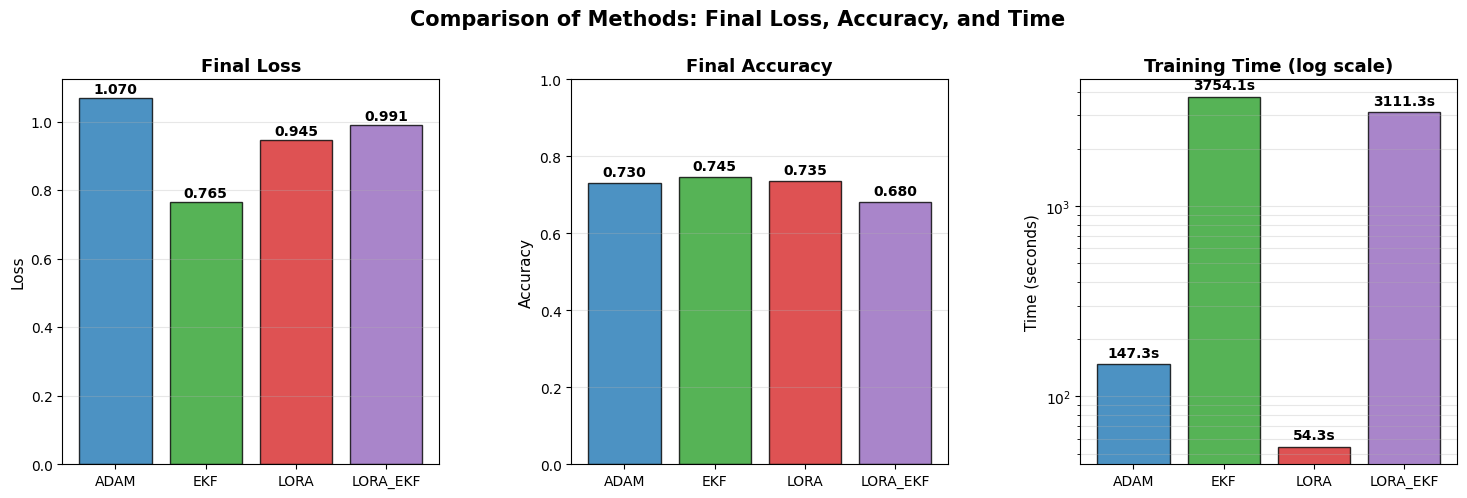

In [15]:
# ============================================================================
# SIMPLIFIED RESULTS VISUALIZATION (FINAL LOSS, ACCURACY, TIME)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Use your actual experiment result variables
results = {
    'adam': ft_results,
    'ekf': ekf_results,
    #'dekf': dekf_results,
    'lora': lora_results,
    'lora_ekf': lora_ekf_results,
    #'lora_dekf': lora_dekf_results
}

def plot_summary_results(results):
    """Plot bar charts for final loss, accuracy, and time across methods."""
    methods = list(results.keys())
    labels = [m.upper() for m in methods]

    # Extract metrics safely (handles missing keys)
    losses = [results[m].get('final_loss', np.nan) for m in methods]
    accs = [results[m].get('final_acc', np.nan) for m in methods]
    times = [results[m].get('time', np.nan) for m in methods]

    colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e', '#8c564b']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.35)

    # -----------------------------
    # Plot 1: Final Loss
    # -----------------------------
    ax = axes[0]
    bars = ax.bar(labels, losses, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title("Final Loss", fontsize=13, fontweight='bold')
    ax.set_ylabel("Loss", fontsize=11)
    for i, v in enumerate(losses):
        ax.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

    # -----------------------------
    # Plot 2: Final Accuracy
    # -----------------------------
    ax = axes[1]
    bars = ax.bar(labels, accs, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title("Final Accuracy", fontsize=13, fontweight='bold')
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_ylim(0, 1)
    for i, v in enumerate(accs):
        ax.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

    # -----------------------------
    # Plot 3: Training Time
    # -----------------------------
    ax = axes[2]
    bars = ax.bar(labels, times, color=colors, alpha=0.8, edgecolor='black')
    ax.set_yscale('log')
    ax.set_title("Training Time (log scale)", fontsize=13, fontweight='bold')
    ax.set_ylabel("Time (seconds)", fontsize=11)
    for i, v in enumerate(times):
        ax.text(i, v * 1.05, f"{v:.1f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', which='both', alpha=0.3)

    plt.suptitle("Comparison of Methods: Final Loss, Accuracy, and Time",
                 fontsize=15, fontweight='bold', y=1.02)
    plt.show()

# Call the plotting function
plot_summary_results(results)